# Chapter 12.2 — Standard Sentiment Analysis

*Course 888102 · International College of Digital Innovation, Chiang Mai University*

Part 12.1 turned thirty noodle-shop reviews into a table of word counts. The counts say what the customers write about, not what they feel. This part adds a list of words that carry an opinion, and ends with one label on every review: positive, negative or neutral.

**In this chapter:** Recap of 12.1 · A sentiment lexicon · The compound score · The rules · All thirty reviews, labeled · Three approaches · Homework



> **Learning objectives.** By the end of this part you should be able to:
>
> - **Look words up in a lexicon** and say what its scores mean.
> - **Work out a compound score** from the word scores, by hand and with the tool.
> - **Apply the rules** for not, really and but, and say how each one changes the score.
> - **Label a set of reviews** and check the labels against the star ratings.



**Contents**

- **12.2.1 · Where Part 12.1 left the reviews** — recap: a table of word counts
- **12.2.2 · A sentiment lexicon** — step 4, and the compound score
- **12.2.3 · The rules** — not, really, but
- **12.2.4 · All thirty reviews, labeled** — the end of step 5
- **12.2.5 · Three approaches** — and where Part 12.3 goes
- **12.2.6 · Glossary** — the terms of this part
- **12.2.7 · Homework** — the sixteen cafe reviews



> **How to use this notebook.** Each idea is explained first, with a small example worked by hand, and then run in code one step per cell. The text above a code cell says what the cell does and why; the Interpretation under it reads the result. The VADER package carries the lexicon and its rules; CountVectorizer from Part 12.1 cuts the text into words.



## 12.2.1 · Where Part 12.1 left the reviews

*recap: a table of word counts*

> **Recap from Part 12.1.** Text collection gave thirty reviews of a noodle shop, each with a 1-to-5 star rating. Preprocessing lowercased them and removed punctuation and symbols; tokenization cut them into words; filtering removed the stop words. The **bag of words** counted what was left: **30 rows by 89 words**. *Delivery* and *price* were the most frequent words, 6 times each.

The counts say what the customers write about. They do not say what the customers feel: in the bag of words, *delicious* and *disaster* are two columns like any others. Steps 4 and 5 of the workflow (Section 12.1.4) add that, with a list of words that carry an opinion.

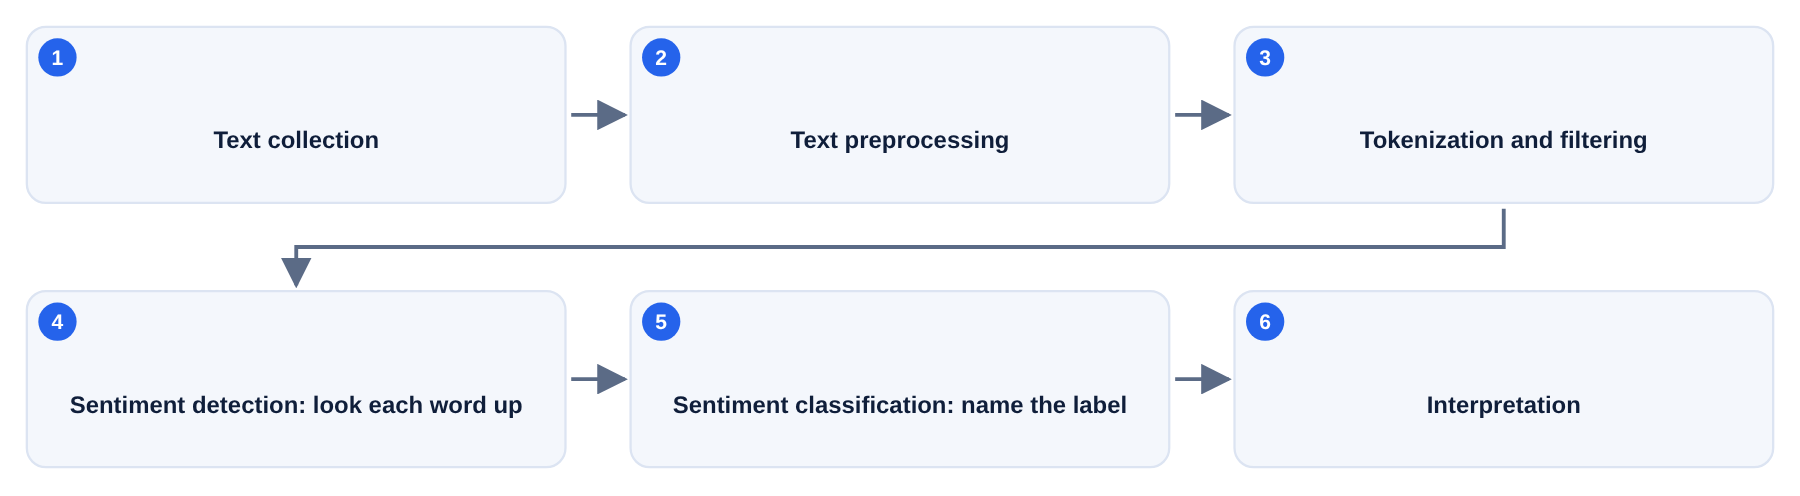

*The six steps of sentiment analysis. This part carries out steps 4 and 5.*



#### Setup

The first cell loads the tools. Colab does not include the VADER sentiment package, so the cell installs it the first time it runs; after that it only imports.



In [1]:
try:
    import vaderSentiment
except ImportError:              # Colab does not include VADER; install it once
    %pip install -q vaderSentiment

import re
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
pd.set_option("display.max_colwidth", 80)
print("pandas", pd.__version__, "· ready")

pandas 3.0.6 · ready


#### The thirty reviews

The thirty reviews of Part 12.1, each with its star rating, numbered 1 to 30.



In [2]:
reviews = pd.DataFrame([
    ["The noodles were delicious and the broth was rich.", 5],
    ["Great value for the price, a big portion for 60 baht.", 5],
    ["Friendly staff and very quick service.", 5],
    ["The delivery was fast and the food arrived hot, perfect.", 5],
    ["The app is easy to use and ordering took one minute.", 4],
    ["Tasty food, fair price, will order again.", 5],
    ["The driver was friendly and arrived early.", 4],
    ["Excellent soup, the best in town.", 5],
    ["Good portions and a fair price.", 4],
    ["The staff were helpful when I changed my order.", 4],
    ["Fast delivery and the packaging kept everything warm.", 5],
    ["Love the new app, the order button is easy to find.", 5],
    ["Fresh vegetables and a wonderful spicy broth.", 5],
    ["A fair price for such a generous bowl.", 4],
    ["The service was quick and the food was great.", 5],
    ["The delivery took two hours and the noodles were cold.", 1],
    ["Terrible service, the staff ignored us.", 1],
    ["Overpriced and disappointing for such a small portion.", 2],
    ["The app crashes every time I open it.", 1],
    ["The driver was rude and the order was wrong.", 1],
    ["The broth was bland and the noodles were a disappointment.", 2],
    ["Slow service and a dirty table.", 2],
    ["The price went up again, not worth it anymore.", 2],
    ["Late delivery and a useless phone line, nobody answered.", 1],
    ["The app is a mess, it logged me out twice during payment.", 2],
    ["Awful food, the meat was not fresh.", 1],
    ["The delivery was late again and the driver was rude.", 1],
    ["Poor value, the portion was tiny for the price.", 2],
    ["Bad packaging, the bag was leaking and the order arrived late.", 1],
    ["The noodles were delicious, but the delivery was a disaster, two hours late.", 2],
], columns=["review", "stars"])
reviews.index = range(1, 31)          # number the reviews 1 to 30
print("shape:", reviews.shape)

shape: (30, 2)


## 12.2.2 · A sentiment lexicon

*step 4, and the compound score*

Section 12.2.1 left the reviews as words with no opinion attached. A lexicon attaches one.

> **Definition.** A **lexicon** is a list of words, each with a sentiment score given by human raters. The VADER lexicon used here holds about 7,500 English words scored from −4, most negative, to +4, most positive. Looking each token up in it is **sentiment detection**.

| Word | Score | Word | Score |
|---|---|---|---|
| **delicious** | +2.7 | bad | −2.5 |
| **good** | +1.9 | terrible | −2.1 |
| **okay** | +0.9 | rude | −2.0 |
| **cold, late, crashes** | not in the lexicon |  |  |



#### The compound score

**Standard sentiment analysis** adds up the scores of a sentence's words and squeezes the sum into one **compound score** between −1 and +1. Two thresholds turn the compound score into the three labels:

$$\text{compound} = \frac{x}{\sqrt{x^2 + 15}}, \qquad x = \text{the sum of the word scores}$$

positive if compound ≥ 0.05, negative if compound ≤ −0.05, neutral in between.

> **Worked example.** *The food was good.* has one scored word, *good*, so $x = 1.9$ and $\text{compound} = 1.9/\sqrt{1.9^2 + 15} = 1.9/4.31 = 0.44$. That is at least 0.05, so the sentence is positive.



#### Where the formula comes from

- **The sum can be any size.** Two strong words give 5 or more, a long complaint −10; a raw sum cannot be compared across sentences of different lengths.
- **Dividing by $\sqrt{x^2 + 15}$ keeps the result between −1 and +1**, because the bottom is always a little larger than $|x|$. The sign of $x$ is kept; a sum of 0 stays 0.
- **Large sums flatten out.** A sum of 2 gives 0.46 and a sum of 8 gives 0.90: each extra positive word adds less than the one before. The 15 is the constant VADER's authors chose to set how fast that happens.

> **A lexicon knows only its list.** *Cold*, *late* and *crashes* have no score. For a noodle shop those are among the commonest complaints, so review 16 (*two hours … cold*) and review 19 (*the app crashes*) have a sum of 0 and are called neutral. The lexicon did not misjudge them; it did not see them.



#### Worked example: a long sentence

A longer review puts the whole computation on one page. Each of its twenty-four words is looked up in turn; six are in the lexicon and eighteen are not:

*The noodles were delicious and the broth was rich, the staff were friendly and helpful, the portion was generous, and the table was dirty.*

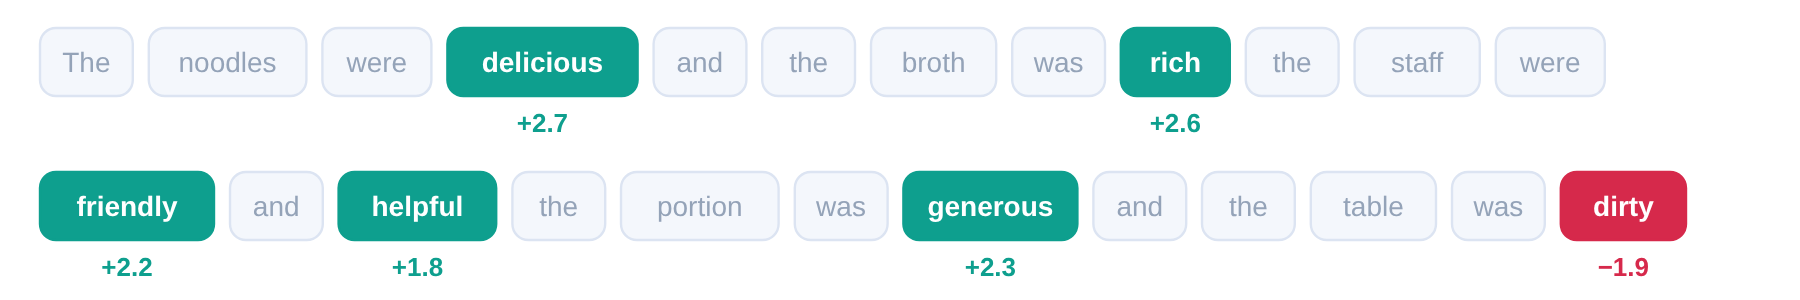

*The twenty-four words. Six carry a score; the other eighteen add nothing.*

| Scored word | delicious | rich | friendly | helpful | generous | dirty |
|---|---|---|---|---|---|---|
| **Score** | +2.7 | +2.6 | +2.2 | +1.8 | +2.3 | −1.9 |

The sum is $x = 2.7 + 2.6 + 2.2 + 1.8 + 2.3 - 1.9 = 9.7$, and the formula gives $\text{compound} = 9.7/\sqrt{9.7^2 + 15} = 9.7/\sqrt{109.09} = 9.7/10.44 = 0.93$. That is at least 0.05, so the review is positive. Three things to notice:

- **Eighteen words add nothing.** *Noodles*, *broth*, *staff* and *table* say what the review is about, not what the customer feels.
- **One complaint subtracts.** *Dirty* takes 1.9 off the 11.6 of the five praises.
- **A long positive review is near +1, not at it.** A sum of 9.7 gives 0.93; the single word *good* gave 0.44.



#### The steps

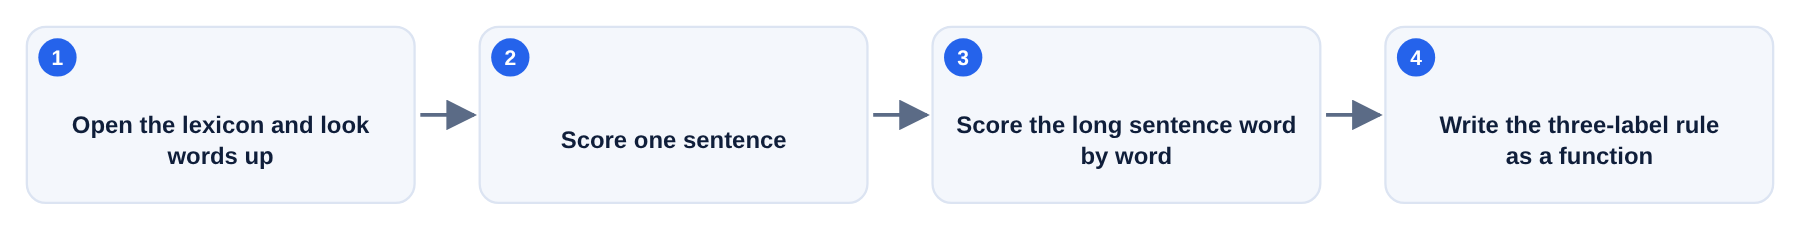

*The code of this section.*



#### The lexicon

The `SentimentIntensityAnalyzer` carries the lexicon as a dictionary, `lexicon`: a word goes in, its score comes out. `.get(word, ...)` returns the second argument for a word the dictionary does not hold.



> **Interpretation.** The scores of the table in Section 12.2.2, and the three complaint words missing from a list of 7,506.



In [3]:
analyzer = SentimentIntensityAnalyzer()
lexicon = analyzer.lexicon
print("words in the lexicon:", len(lexicon))
for word in ["delicious", "good", "okay", "bad", "terrible", "rude", "cold", "late", "crashes"]:
    print(f"{word:10s} {lexicon.get(word, 'not in the lexicon')}")

words in the lexicon: 7506
delicious  2.7
good       1.9
okay       0.9
bad        -2.5
terrible   -2.1
rude       -2.0
cold       not in the lexicon
late       not in the lexicon
crashes    not in the lexicon


#### One sentence, scored

`polarity_scores` looks every word up, applies the rules of Section 12.2.3, and returns four numbers. `compound` is the score of the formula; `neg`, `neu` and `pos` are the shares of the sentence that were negative, neutral and positive.

$$\text{compound} = \frac{x}{\sqrt{x^2 + 15}}, \qquad x = \text{the sum of the word scores}$$

positive if compound ≥ 0.05, negative if compound ≤ −0.05, neutral in between.



> **Interpretation.** compound 0.4404, the 0.44 of the worked example. *Good* is the only word with an opinion, so pos is about half and neg is zero.



In [4]:
analyzer.polarity_scores("The food was good.")

{'neg': 0.0, 'neu': 0.508, 'pos': 0.492, 'compound': 0.4404}

#### A long sentence, word by word

The worked example above, in code. The sentence is cut into words, each word is looked up with `lexicon.get`, which returns nothing for a word the lexicon does not hold, and `dropna` keeps the words that have a score. Their sum goes through the formula, and the last line asks the tool for the same sentence.

$$\text{compound} = \frac{x}{\sqrt{x^2 + 15}}, \qquad x = \text{the sum of the word scores}$$

positive if compound ≥ 0.05, negative if compound ≤ −0.05, neutral in between.



> **Interpretation.** The six rows of the table in the worked example, with the row number saying where each word sits in the sentence. x is 9.7, and the compound score by hand and by the tool are both 0.9287: the tool does nothing more than the lookup, the sum and the formula.



In [5]:
sentence = ("The noodles were delicious and the broth was rich, the staff were friendly and helpful, "
            "the portion was generous, and the table was dirty.")
words = re.findall(r"[a-z]+", sentence.lower())
scored = pd.DataFrame({"word": words, "score": [lexicon.get(w) for w in words]}).dropna()
print(len(words), "words,", len(scored), "with a score")
x = scored["score"].sum()
print("x =", round(x, 1))
print("compound by hand:", round(x / (x**2 + 15) ** 0.5, 4))
print("compound by VADER:", analyzer.polarity_scores(sentence)["compound"])
scored

24 words, 6 with a score
x = 9.7
compound by hand: 0.9287
compound by VADER: 0.9287


,word,score
3,delicious,2.7
8,rich,2.6
12,friendly,2.2
14,helpful,1.8
18,generous,2.3
23,dirty,-1.9


#### Try it: a second long sentence

> **Try it.** Work this sentence by hand first, then put it in the cell above and run it: *Excellent broth and friendly staff, a fair price, and a rude driver.* Four of its words are in the lexicon: *excellent* +2.7, *friendly* +2.2, *fair* +1.3, *rude* −2.0.
>
> *Answer.* $x = 2.7 + 2.2 + 1.3 - 2.0 = 4.2$, and $4.2/\sqrt{4.2^2 + 15} = 4.2/5.71 = 0.74$: positive. The tool prints 0.7351.



#### The three-label rule as a function

`sentiment_of` is the whole classifier of standard sentiment analysis: one call to `polarity_scores`, two thresholds, three labels. It is used on every sentence from here on.



In [6]:
def sentiment_of(text):
    compound = analyzer.polarity_scores(text)["compound"]
    if compound >= 0.05:
        return "positive"
    if compound <= -0.05:
        return "negative"
    return "neutral"

sentiment_of("The food was good.")

'positive'

## 12.2.3 · The rules

*not, really, but*

A lexicon alone gives *not good* the same score as *good*, since both contain *good*. **Rule-based** sentiment analysis adds rules for how words change each other. VADER applies three kinds, each with a fixed number:

| Rule | What it does | Worked on good (+1.9) | Compound |
|---|---|---|---|
| **Negation** | *not* or *never* before a word multiplies its score by −0.74 | *not good*: 1.9 × (−0.74) = −1.41 | −0.34 |
| **Intensifier** | *really* or *very* adds 0.293 to the size of the next word's score; each *!* adds 0.292 | *really good!*: 1.9 + 0.293 + 0.292 = 2.49 | +0.54 |
| **Contrast** | *but*: words before it count half, words after it count one and a half times | *good, but … really bad*: 1.9 × 0.5 + (−2.5 − 0.293) × 1.5 = −3.24 | −0.64 |

Each compound in the last column is the formula of Section 12.2.2 applied to the sum: $-1.41/\sqrt{1.41^2 + 15} = -0.34$, and so on.

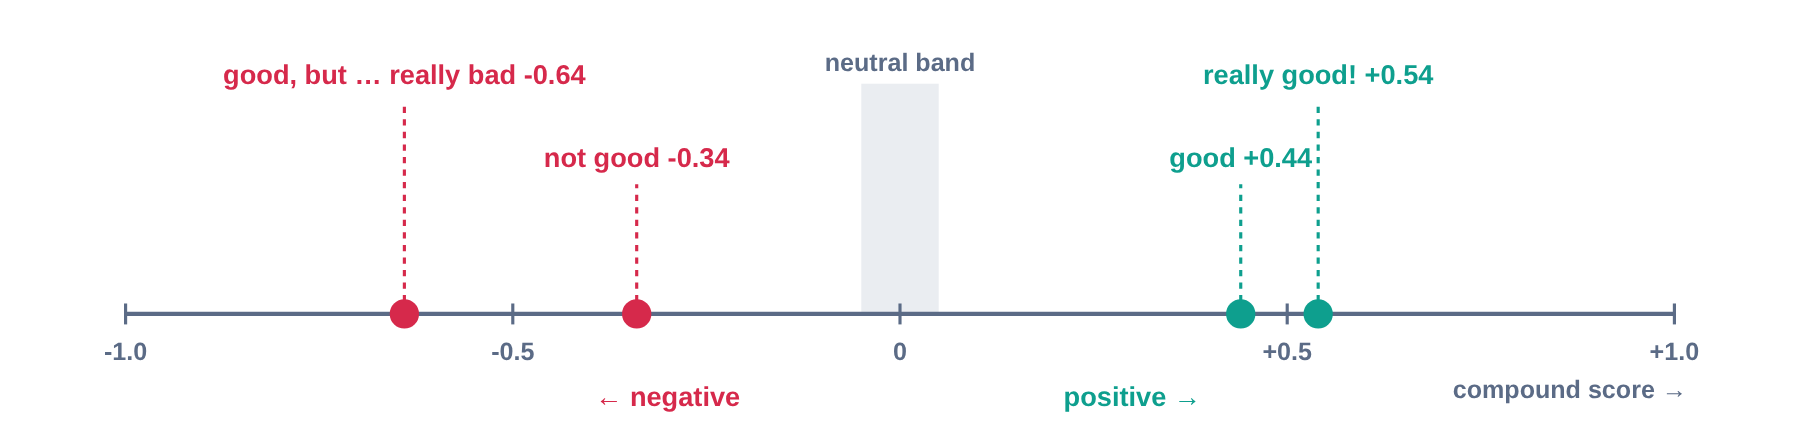

*The four sentences on the compound score's scale. The shaded band between −0.05 and +0.05 is labeled neutral.*



#### The rules and the word order

The bag of words of Part 12.1 kept which words a review used and lost their order. The rules put some of that order back: *not* acts on the word after it, and *but* on everything that follows. That is why the tool reads each sentence whole rather than its word counts.



#### The four sentences

The four sentences of the table are scored by the tool, with the label beside each compound score, so each row can be checked against the hand calculation.

$$\textit{not}: \times(-0.74) \qquad \textit{really}: +0.293 \qquad \textit{!}: +0.292 \qquad \textit{but}: \text{before} \times 0.5,\ \text{after} \times 1.5$$



> **Interpretation.** The table's four numbers, from the tool:
>
> - ***not good*** −0.34: the negation rule flipped the sign of *good*.
> - ***really good!*** +0.54: the intensifier and the exclamation mark each pushed the score further from 0.
> - ***good, but … really bad*** −0.64: the second half counts more, so the sentence is negative although it contains a positive word.



In [7]:
sentences = ["The food was good.",
             "The food was not good.",
             "The food was really good!",
             "The hotel was good, but the food was really bad."]
pd.DataFrame({"sentence": sentences,
              "compound": [analyzer.polarity_scores(s)["compound"] for s in sentences],
              "sentiment": [sentiment_of(s) for s in sentences]})

,sentence,compound,sentiment
0,The food was good.,0.4404,positive
1,The food was not good.,-0.3412,negative
2,The food was really good!,0.5400,positive
3,"The hotel was good, but the food was really bad.",-0.6416,negative


#### Try it: a contrast word without a rule

> **Try it.** Add *Although the food was good, the service was terrible.* to the list and run the cell again.
>
> *Answer.* It scores only −0.05. VADER has a rule for *but* and none for *although*, so the two halves nearly cancel. Every rule list has gaps.



#### Worked example: a long sentence with the rules

One longer review puts all three rules to work at once:

*The soup was really delicious, but the meat was not fresh and the driver was rude!*

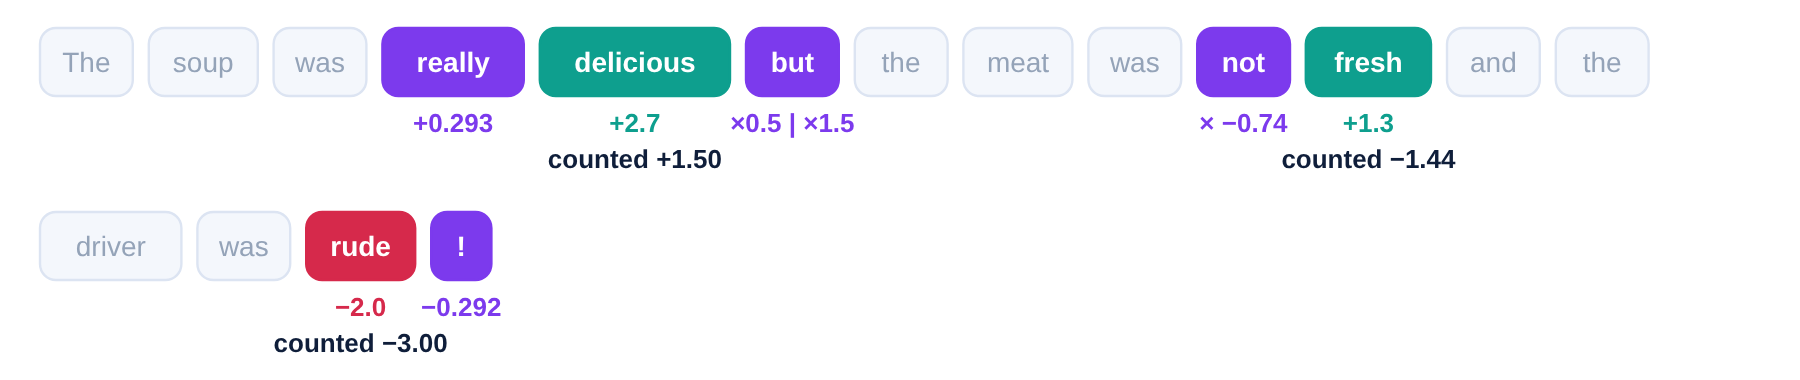

*Three scored words and four rule words. Under each scored word: its lexicon score, then the score counted after the rules.*

| Scored word | Lexicon | Rules applied | Counted |
|---|---|---|---|
| ***really* delicious** | +2.7 | +0.293 for *really*, then × 0.5 before *but* | (2.7 + 0.293) × 0.5 = **+1.50** |
| ***not* fresh** | +1.3 | × −0.74 for *not*, then × 1.5 after *but* | 1.3 × (−0.74) × 1.5 = **−1.44** |
| **rude** | −2.0 | × 1.5 after *but* | −2.0 × 1.5 = **−3.00** |
| **!** |  | 0.292 away from zero; the sum is negative | **−0.29** |

The counted scores add to $x = 1.50 - 1.44 - 3.00 - 0.29 = -3.24$, and $-3.24/\sqrt{3.24^2 + 15} = -3.24/5.05 = -0.64$: negative. Without the rules the same three words would add to $2.7 + 1.3 - 2.0 = 2.0$ and a compound of $+0.46$, the wrong sign. The lexicon alone reads the praise; the rules read the *but*, the *not* and the *!*.



#### The long sentence with the rules

The table of the worked example, built in code: the lexicon score of each word, the rule applied to it, and the counted score, with the exclamation mark as a row of its own. The counted scores are summed and put through the formula, and the tool is asked for the same sentence.

$$\text{compound} = \frac{x}{\sqrt{x^2 + 15}}, \qquad x = \text{the sum of the counted scores}$$

each word's score is changed by the rules before it is counted.



> **Interpretation.** x is −3.2385 and both compound scores are −0.6415: the four rows of the worked example, counted exactly as the tool counts them. The exclamation mark has no lexicon score, so its lexicon entry prints as NaN, not a number. The three rules together turned a sum of +2.0 into −3.24.



In [8]:
sentence = "The soup was really delicious, but the meat was not fresh and the driver was rude!"
counted = pd.DataFrame({
    "word":    ["really delicious", "not fresh", "rude", "!"],
    "lexicon": [lexicon["delicious"], lexicon["fresh"], lexicon["rude"], None],
    "rule":    ["+0.293, then x 0.5 before but", "x -0.74, then x 1.5 after but",
                "x 1.5 after but", "0.292 away from zero"],
    "counted": [(lexicon["delicious"] + 0.293) * 0.5, lexicon["fresh"] * -0.74 * 1.5,
                lexicon["rude"] * 1.5, -0.292],
})
x = counted["counted"].sum()
print("x =", round(x, 4))
print("compound by hand:", round(x / (x**2 + 15) ** 0.5, 4))
print("compound by VADER:", analyzer.polarity_scores(sentence)["compound"])
counted.round(3)

x = -3.2385
compound by hand: -0.6415
compound by VADER: -0.6415


,word,lexicon,rule,counted
0,really delicious,2.7,"+0.293, then x 0.5 before but",1.497
1,not fresh,1.3,"x -0.74, then x 1.5 after but",-1.443
2,rude,-2.0,x 1.5 after but,-3.000
3,!,NaN,0.292 away from zero,-0.292


#### Try it: a second sentence with the rules

> **Try it.** Work this one by hand, then check it with the tool: *The broth was really good, but the service was slow and the staff were not friendly.* In the lexicon: *good* +1.9 and *friendly* +2.2; *slow* is not.
>
> *Answer.* *really good* counts $(1.9 + 0.293) \times 0.5 = 1.10$; *not friendly* counts $2.2 \times (-0.74) \times 1.5 = -2.44$; *slow* counts nothing. $x = -1.35$ and $-1.35/\sqrt{1.35^2 + 15} = -0.33$: negative, although both lexicon words are positive. The tool prints −0.3282.



## 12.2.4 · All thirty reviews, labeled

*the end of step 5*

The lexicon, the rules and the three-label function are in place. Applied to all thirty reviews, they finish step 5: one compound score and one label per review. The star ratings, kept aside since Part 12.1, then say how often the label is right.

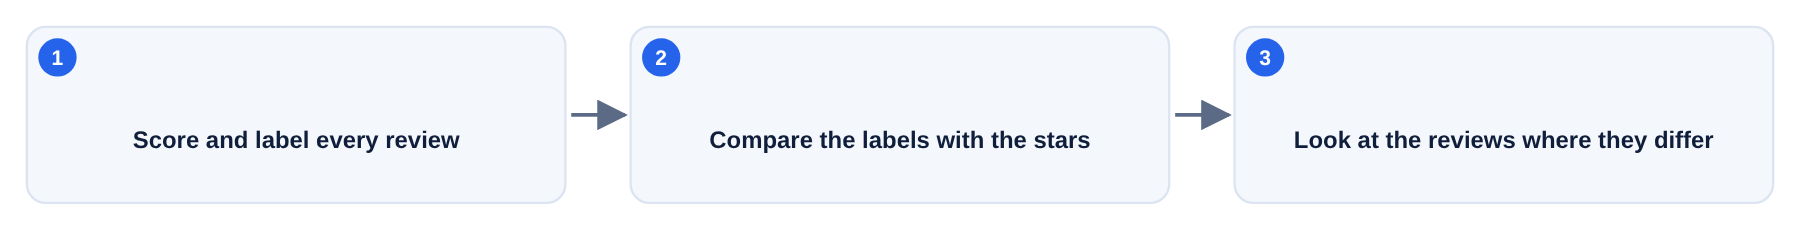

*The code of this section.*



#### A score and a label for every review

Two new columns: the compound score of each review, and its label from sentiment_of. `value_counts` counts the labels.



> **Interpretation.** 15 positive, 13 negative, 2 neutral.



In [9]:
reviews["compound"] = [analyzer.polarity_scores(t)["compound"] for t in reviews["review"]]
reviews["sentiment"] = reviews["review"].apply(sentiment_of)
reviews["sentiment"].value_counts()

sentiment
positive    15
negative    13
neutral      2
Name: count, dtype: int64

#### The labels against the stars

A review rated 4 or 5 stars is taken as positive and one rated 1 or 2 as negative. `pd.crosstab` counts how the two agree.



> **Interpretation.** 28 of 30. All 15 reviews rated 4 or 5 stars are positive; of the 15 rated 1 or 2, 13 are negative and 2 are neutral. The lexicon never called a complaint positive.



In [10]:
star_label = reviews["stars"].map(lambda s: "positive" if s >= 4 else "negative")
print("the label agrees with the stars on", (reviews["sentiment"] == star_label).sum(), "of 30 reviews")
pd.crosstab(star_label, reviews["sentiment"], rownames=["stars"], colnames=["lexicon"])

the label agrees with the stars on 28 of 30 reviews


lexicon,negative,neutral,positive
stars,,,
negative,13,2,0
positive,0,0,15


#### The two reviews it missed

The rows labeled neutral are pulled out, with review 30 beside them because it mixes praise and a complaint.



> **Interpretation.** Reading the three rows:
>
> - **Reviews 16 and 19** score exactly 0. Their complaint words, *cold* and *crashes*, are not in the lexicon, so the sum of the word scores is 0.
> - **Review 30** is negative at −0.65: after *but*, *disaster* (−3.1) outweighs *delicious* (+2.7).



In [11]:
reviews.loc[[16, 19, 30], ["review", "stars", "compound", "sentiment"]]

,review,stars,compound,sentiment
16,The delivery took two hours and the noodles were cold.,1,0.0000,neutral
19,The app crashes every time I open it.,1,0.0000,neutral
30,"The noodles were delicious, but the delivery was a disaster, two hours late.",2,-0.6486,negative


#### Try it: other reviews

> **Try it.** Run `reviews.sort_values("compound")` in a new cell to see all thirty from most negative to most positive. Where does review 3 (*Friendly staff and very quick service*) sit, and why is it not higher?
>
> *Answer.* At +0.49. *Friendly* is scored and *very* is an intensifier, but *quick* is not in the lexicon.



## 12.2.5 · Three approaches

*and where Part 12.3 goes*

This part used one of three ways to do steps 4 and 5:

| Approach | How it works | Strength | Limit |
|---|---|---|---|
| **Lexicon- and rule-based** | a list of scored words and hand-written rules | needs no training data; every label can be explained by a word and a rule | blind to any word not on its list |
| **Machine-learning-based** | a classifier learns which words go with which label from reviews that already carry one (Chapter 10, with the bag of words as features) | learns words no lexicon has | knows only the words its training reviews contain |
| **Hybrid** | a learned classifier with a lexicon and rules on top | handles rare words, negation and contrast | the most work to build; what most commercial systems use |



#### Where Part 12.2 leaves us

- **A lexicon plus rules reads opinion**: word scores give a compound score, the rules for *not*, *really* and *but* correct it, and two thresholds give the label. A twenty-four-word review worked by hand gave 0.93; the tool gave 0.9287.
- **15 positive, 13 negative, 2 neutral**, agreeing with the stars on 28 of 30.
- **A lexicon knows only its list**: two plain complaints were called neutral.

> **Next: Part 12.3.** Every review now has one label. Part 12.3 asks what that label hides: how strong the opinion is, which emotion it carries, and which part of the shop it is about, and it turns the answers into what the owner should fix first.



## 12.2.6 · Glossary

*the terms of this part*

The terms of Part 12.1 (token, stop words, bag of words) are in its own glossary.

| Term | Meaning |
|---|---|
| **Lexicon** | A list of words, each with a sentiment score. |
| **Sentiment detection** | Step 4: finding the words that carry an opinion by looking them up. |
| **Compound score** | One number between −1 and +1 summing up the scores of a sentence's words. |
| **Standard sentiment analysis** | Three labels, positive, negative or neutral, cut from the compound score at ±0.05. |
| **Rule-based sentiment analysis** | A lexicon with rules for how words change each other. |
| **Negation, intensifier, contrast** | The three kinds of rule: not flips a score, really strengthens it, but gives the second half more weight. |



## 12.2.7 · Homework

*the sixteen cafe reviews*

The exercises repeat steps 4 and 5 on the cafe reviews of Part 12.1's homework, in the order this part taught them. Each exercise has a code cell for your work and a text cell for your answer.

**Student information**: double-click this cell to edit it and fill in your details.

**Name:** ____________________________

**Student ID:** ______________________

**Date:** ____________________________



#### The homework data: sixteen cafe reviews

*run this cell, but do not modify it*

Run this cell once and do not edit it. It defines `cafe`, sixteen reviews of a cafe with their star ratings, and loads the tools again so the homework works even if the cells above were not run.



In [12]:
# ------- RUN THIS CELL, BUT DO NOT MODIFY IT -------
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

cafe = pd.DataFrame([
    ["The coffee was excellent and the croissant was fresh.", 5],
    ["Friendly barista and a cozy place to study.", 5],
    ["Great latte for a fair price.", 4],
    ["The wifi is fast and the seats are comfortable.", 4],
    ["Lovely cake, I will come back tomorrow.", 5],
    ["The staff remembered my order, very kind.", 5],
    ["Good coffee, but the seats are hard.", 4],
    ["A quiet corner and the best espresso in the city.", 5],
    ["The coffee was lukewarm and the cup was chipped.", 1],
    ["Rude staff and a dirty table.", 1],
    ["Too expensive and disappointing for such a small cup.", 2],
    ["The wifi keeps dropping, very frustrating.", 2],
    ["The cake was stale and the coffee was not good.", 1],
    ["We waited twenty minutes, terrible service.", 2],
    ["The price is fair, but the barista was unfriendly.", 2],
    ["No seats at all and the music is too loud.", 1],
], columns=["review", "stars"])
cafe.index = range(1, 17)
analyzer = SentimentIntensityAnalyzer()
print("cafe reviews:", len(cafe))

cafe reviews: 16


#### Exercise 1 — The compound score by hand

A customer writes: *The coffee was excellent and the cake was lovely, the barista was friendly, the price was fair, and the music was awful.* Look up each word in the lexicon and list the ones that have a score, add the scores into $x$, and work out the compound score with the formula of Section 12.2.2, showing every step. Check your number against `polarity_scores`, and give the review its label.

*Hint:* the long sentence of Section 12.2.2, `analyzer.lexicon.get(word, 'not in the lexicon')`.



In [13]:
# YOUR CODE HERE (Exercise 1)

#### Your answer: Exercise 1

*Double-click this cell and type your answer here.*



#### Exercise 2 — A review the lexicon cannot see

Look up every token of review 9 (without stop words) in the lexicon, and score the review. Which label does it get, and what is its star rating? Explain the result using the words that are and are not in the lexicon.

*Hint:* Section 12.2.2, and Part 12.1's `CountVectorizer(stop_words="english").build_analyzer()`.



In [14]:
# YOUR CODE HERE (Exercise 2)

#### Your answer: Exercise 2

*Double-click this cell and type your answer here.*



#### Exercise 3 — The negation rule

Review 13 contains *good*, a positive word, yet it is a complaint. Score the whole review, and work out what its compound score would be if *not* were ignored. Which rule of Section 12.2.3 makes the difference?

*Hint:* the formula of Section 12.2.2 on the sum of the scores.



In [15]:
# YOUR CODE HERE (Exercise 3)

#### Your answer: Exercise 3

*Double-click this cell and type your answer here.*



#### Exercise 4 — All sixteen, labeled

Write the three-label function of Section 12.2.2, label all sixteen reviews, and count the labels. Taking 4 or 5 stars as positive and 1 or 2 as negative, on how many reviews does the label agree with the stars? Name any review where it does not and say why.

*Hint:* Section 12.2.4, `pd.crosstab`.



In [16]:
# YOUR CODE HERE (Exercise 4)

#### Your answer: Exercise 4

*Double-click this cell and type your answer here.*



#### Bonus: the rules on review 7 and review 15

Reviews 7 and 15 both contain *but*. Score each whole review, then score the part before and the part after *but* separately. Use the contrast rule of Section 12.2.3 to explain why each whole review gets the label it does.



In [17]:
# YOUR CODE HERE (Bonus)

#### Your answer: the bonus question

*Double-click this cell and type your answer here.*



#### Submission checklist

- [ ] Filled in your student information above
- [ ] Ran the dataset cell without modifying it
- [ ] Answered all 4 exercises plus the bonus
- [ ] Notebook runs top to bottom without errors (Runtime > Restart and run all)
- [ ] Saved and submitted the `.ipynb` file

